# Dependency package

In [1]:
import os
import time
import numpy as np

import mne
from mne.channels import make_standard_montage
# from mne.decoding import CSP

import sklearn
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import scipy
from scipy import stats
from scipy.io import loadmat
from scipy.signal import welch

from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

import pyriemann
from pyriemann.clustering import Kmeans as pyKmeans

print(f"numpy version: {np.__version__}")
print(f"mne version: {mne.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"pyriemann version: {pyriemann.__version__}")
start_time = time.time()

numpy version: 2.2.6
mne version: 1.10.1
sklearn version: 1.7.2
scipy version: 1.15.3
pyriemann version: 0.10


# Dataset Setting

In [2]:
def DatasetConfigSelect(Dataset_Selection:int=0) -> dict:
    """
    設定並回傳指定資料集的路徑、參數與前處理設定。

    Args:
        Dataset_Selection: 資料集選擇索引。
            0: BCICIV_2a
            1: BCICIV_2b
            2: BCICIV_1

    Returns:
        dict:
            - 'dataFormat' (str): 資料格式。
                0: gdf
                1: mat
            - 'dirPath' (str): EEGs存放的根目錄路徑。
            - 'participants' (list): 受試者編號清單。
            - 'filenamePrefix' (str): EEGs檔案名稱前綴。
            - 'filenamePostfix' (str): EEGs檔案名稱後綴。
            - 'target_keys' (list): 感興趣的事件或標記點。
            - 'channel_rename_map' (dict): 通道名稱轉換對照表。
            - 'channel_types' (dict): 通道型別定義 (如 eeg, eog)。
            - 'downsamplingFreq' (int): 降採樣後的頻率。
            - 'saveResultPath' (str): 分析結果儲存路徑。

    Notes:
        EEG 原始資料的完整讀取路徑遵循以下邏輯：
        Full_Path = dirPath + filenamePrefix + participant_id + filenamePostfix
    """

    match Dataset_Selection:
        case 0:
            dataFormat = 0
            dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
            participants = [] # EEG-MI 受試者
            participantsNum = 9 # EEG-MI 受試者人數
            for i in range(1,participantsNum+1,1):
                participants = participants + [f'A0{i}T']  # bci4_2A
            filenamePrefix = ""
            filenamePostfix = '.gdf'
            target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
            # BCI4 2A 資料集電擊轉換成標準10-20系統
            channel_rename_map = {
                'EEG-Fz' : 'Fz'  ,
                'EEG-0'  : 'FC3' ,
                'EEG-1'  : 'FC1' ,
                'EEG-2'  : 'FCz' ,
                'EEG-3'  : 'FC2' ,
                'EEG-4'  : 'FC4' ,
                'EEG-5'  : 'C5'  ,
                'EEG-C3' : 'C3'  ,
                'EEG-6'  : 'C1'  ,
                'EEG-Cz' : 'Cz'  ,
                'EEG-7'  : 'C2'  ,
                'EEG-C4' : 'C4'  ,
                'EEG-8'  : 'C6'  ,
                'EEG-9'  : 'CP3' ,
                'EEG-10' : 'CP1' ,
                'EEG-11' : 'CPz' ,
                'EEG-12' : 'CP2' ,
                'EEG-13' : 'CP4' ,
                'EEG-14' : 'P1'  ,
                'EEG-Pz' : 'Pz'  ,
                'EEG-15' : 'P2'  ,
                'EEG-16' : 'POz' ,
                'EOG-left'   : 'EOG-left',
                'EOG-central': 'EOG-central',
                'EOG-right'  : 'EOG-right'
            }
            channel_types = {
                'EEG-Fz' : 'eeg',
                'EEG-0'  : 'eeg',
                'EEG-1'  : 'eeg',
                'EEG-2'  : 'eeg',
                'EEG-3'  : 'eeg',
                'EEG-4'  : 'eeg',
                'EEG-5'  : 'eeg',
                'EEG-C3' : 'eeg',
                'EEG-6'  : 'eeg',
                'EEG-Cz' : 'eeg',
                'EEG-7'  : 'eeg',
                'EEG-C4' : 'eeg',
                'EEG-8'  : 'eeg',
                'EEG-9'  : 'eeg',
                'EEG-10' : 'eeg',
                'EEG-11' : 'eeg',
                'EEG-12' : 'eeg',
                'EEG-13' : 'eeg',
                'EEG-14' : 'eeg',
                'EEG-Pz' : 'eeg',
                'EEG-15' : 'eeg',
                'EEG-16' : 'eeg',
                'EOG-left'   : 'eog',
                'EOG-central': 'eog',
                'EOG-right'  : 'eog'
            }
            downsamplingFreq = None
        case 1:
            dataFormat = 0
            dirPath = f'../../dataset/BCICIV_2b_gdf/'
            participants = []
            participantsNum = 9
            participantsId = ['B0103T','B0203T','B0303T','B0403T','B0503T','B0603T','B0703T','B0803T','B0903T']
            filenamePrefix = ''
            filenamePostfix = '.gdf'
            for i in participantsId:
                participants = participants + [i]  # bci4_2B
            target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
            # BCI4 2B 資料集電擊轉換成標準10-20系統
            channel_rename_map = {
                'EEG:C3' : 'C3'  ,
                'EEG:Cz' : 'Cz'  ,
                'EEG:C4' : 'C4'  ,
                'EOG:ch01':'EOG:ch01',
                'EOG:ch02':'EOG:ch02',
                'EOG:ch03':'EOG:ch03'
            }
            channel_types = {
                'EEG:C3'   : 'eeg',
                'EEG:Cz'   : 'eeg',
                'EEG:C4'   : 'eeg',
                'EOG:ch01' : 'eog',
                'EOG:ch02' : 'eog',
                'EOG:ch03' : 'eog'
            }
            downsamplingFreq = None
        case 2:
            dataFormat = 1
            dirPath = f'../../dataset/BCICIV_1calib_1000Hz_mat/'
            participants = []
            participantsNum = 3
            participantsId = ['ds1b','ds1c','ds1g']
            filenamePrefix = 'BCICIV_calib_'
            filenamePostfix = '_1000Hz.mat'
            for i in participantsId:
                participants = participants + [i]  # bci4_1
            target_keys = ['Left', 'Right'] # 任務
            # BCI4 2B 資料集電擊轉換成標準10-20系統
            channel_rename_map = None
            channel_types = None
            downsamplingFreq = 250

    saveResultPath = './results/' # 結果儲存資料夾
    try:
        os.mkdir(saveResultPath) # 創建結果儲存資料夾
        os.mkdir(saveResultPath +'./confuseMatrix/') # 創建結果儲存資料夾
        print(f"Create Result Dir Successful.")
    except:
        pass

    return {
        'dataFormat': dataFormat,
        'dirPath': dirPath,
        'participants': participants,
        'filenamePrefix': filenamePrefix,
        'filenamePostfix': filenamePostfix,
        'target_keys': target_keys,
        'channel_rename_map': channel_rename_map,
        'channel_types': channel_types,
        'downsamplingFreq': downsamplingFreq,
        'saveResultPath': saveResultPath,
        }

# Pre-Processing Setting

In [3]:
class Preprocessing:
    """
    設定 EEG 資料預處理與特徵提取的相關參數。

    Attr:
        fs: 取樣頻率。
        lowcut: 濾波器最小頻率。
        highcut: 濾波器最大頻率。
        filter_order: 濾波器階數。
        iir_params: 濾波器設定。
        time_interval: 選取片段時間多長。
        tmin: 選取從cued開始片段時間。
        tmax: 選取從cued開始最大時間,
        M=4
    """

    # band pass filter
    fs = 250
    lowcut = 8
    highcut = 30
    filter_order = 8
    filter_type = 'butter' # Butterworth
    iir_params = dict(order=filter_order, ftype=filter_type)

    # 擷取實驗時間，0秒是cued開始
    # C: number of channels
    # P: number of temporal points
    # N: number of trials
    # (tmax-tmin)*250+1=500
    # tmax = (P-1)/fs+tmin
    time_interval = 3.5
    P = time_interval*fs
    tmin = 0.5
    tmax = (P-1)/fs+tmin

    # CSP M值
    M = 4
    @classmethod
    def print_time_info(self):
        print(f"Time from {Preprocessing.tmin} s to {Preprocessing.tmax} s, sample point: {Preprocessing.P}")

    @classmethod
    def Dataset_Epocher(self, Dataset_Selection_List:list=[0]) -> dict:
        """
        將選擇的Dataste轉換成MNE Epoch格式。

        Args:
            Dataset_Selection_List: 根據Dataset_Setter的所有選擇的資料集。
                0: BCICIV_2a
                1: BCICIV_2b
                2: BCICIV_1

        Return:
            dict: 以受試者編號為Key的字典。
                格式為 { 'subject_id': mne.Epochs Object }。
        """

        epochs = {}
        for Dataset_Selection in Dataset_Selection_List:
            DatasetConfig = DatasetConfigSelect(Dataset_Selection=Dataset_Selection)
            montage = make_standard_montage('standard_1020')
            if DatasetConfig['channel_rename_map']:
                eeg_only_channels = [
                    name
                    for name in DatasetConfig['channel_rename_map'].values()
                    if not name.startswith('EOG')
                ]
            else:
                eeg_only_channels = None

            for subject in DatasetConfig['participants']:
                filePath = DatasetConfig['dirPath'] + f"./{DatasetConfig['filenamePrefix']}{subject}{DatasetConfig['filenamePostfix']}"
                match DatasetConfig['dataFormat']:
                    case 0:
                        try:
                            raw = mne.io.read_raw_gdf(filePath, preload=True, verbose="ERROR")
                        except Exception as e:
                            print(f"讀取 GDF 檔案時發生錯誤: {e}")
                            raise
                    case 1:
                        try:
                            mat_data = loadmat(filePath, struct_as_record=False, squeeze_me=True)
                            eeg_data = mat_data['cnt']     # 這是訊號矩陣 (Time x Channels)
                            sfreq = mat_data['nfo'].fs     # 採樣率
                            ch_names = mat_data['nfo'].clab # 通道名稱
                            classes = mat_data['nfo'].classes
                            events_sample = mat_data['mrk'].pos - 1
                            events_id = np.where(mat_data['mrk'].y == -1, 1, 2)
                            info = mne.create_info(ch_names=list(ch_names), sfreq=sfreq, ch_types='eeg', verbose='Error')
                            raw = mne.io.RawArray(eeg_data.T * 1e-6, info, verbose='Error')
                            events = np.column_stack((
                                events_sample,
                                np.zeros_like(events_sample, dtype=int),
                                events_id.astype(int)
                            ))
                            mapping = {1: 'Left', 2: 'Right'}
                            annot = mne.annotations_from_events(
                                events=events,
                                sfreq=raw.info['sfreq'],
                                event_desc=mapping
                            )
                            raw.set_annotations(annot)
                        except Exception as e:
                            print(f"讀取 GDF 檔案時發生錯誤: {e}")
                            raise
                ## Raw setting
                if DatasetConfig['channel_types']:
                    raw.set_channel_types(DatasetConfig['channel_types'], verbose="ERROR") # 設定電擊種類是EEG還是EOG
                if DatasetConfig['channel_rename_map']:
                    raw.rename_channels(DatasetConfig['channel_rename_map'], verbose="ERROR") # 重新命名電擊名稱符合10-20系統
                if DatasetConfig['downsamplingFreq']:
                    raw.resample(sfreq=DatasetConfig['downsamplingFreq']) # downsampling
                raw.set_eeg_reference([], verbose="ERROR") # 設定reference電擊
                raw.set_montage(montage, on_missing='ignore', verbose="ERROR") # 設定10-20系統

                ## Regression
                # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
                # model.fit(raw)
                # raw = model.apply(raw)
                if eeg_only_channels:
                    raw.pick_channels(eeg_only_channels, verbose="ERROR") # Remove EOG data
                raw.filter( # Bandpass filter
                    l_freq=Preprocessing.lowcut,
                    h_freq=Preprocessing.highcut,
                    method='iir',
                    iir_params=Preprocessing.iir_params,
                    verbose="ERROR"
                )
                ## 選取事件做成epoch
                events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
                kept_event_ids = {
                    key: value
                    for key, value in event_id.items()
                    if key in DatasetConfig['target_keys']
                }
                events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
                new_id_mapping = {old_id: i for i, old_id in enumerate(kept_event_ids.values())}
                kept_event_ids = {key: i for i, key in enumerate(kept_event_ids.keys())}
                for i in range(len(events_of_interest)):
                    old_val = events_of_interest[i, 2]
                    events_of_interest[i, 2] = new_id_mapping[old_val]
                baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
                epoch = mne.Epochs(
                    raw,
                    events_of_interest,
                    event_id=kept_event_ids,
                    tmin=Preprocessing.tmin,
                    tmax=Preprocessing.tmax,
                    baseline=baseline,
                    preload=True,        # 將數據載入內存
                    proj=False,           # 暫時不應用投影
                    verbose="ERROR"
                )
                epochs[subject] = epoch
                print(f"{subject} epoch create successful")

        return epochs

    @classmethod
    def Align_Channels(self, epochs:dict) -> dict:
        """
        統一所有受試者Epoch物件中的通道配置, 會受限於最小的。

        Args:
            dict: 以受試者編號為Key的字典。
                格式為 { 'subject_id': mne.Epochs Object }。

        Return:
            dict: 以受試者編號為Key的字典。
                格式為 { 'subject_id': mne.Epochs Object }。
        """
        intersection_channel = []
        for idx, epoch in enumerate(epochs.values()):
            if idx==0:
                intersection_channel = epoch.ch_names
            else:
                intersection_channel = list(set(epoch.ch_names) & set(intersection_channel))
        intersection_channel_Num = len(intersection_channel)
        print(f"已選擇{intersection_channel_Num}個channels")
        for subject in epochs.keys():
            epochs[subject].pick(intersection_channel)

        return epochs

# Feature Transfer (CSP)

In [4]:
class CSP(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=4, reg=1e-10):
        self.n_components = n_components
        self.reg = reg # 我們推導中的 gamma
        self.filters_ = None

    def __trace_normalization(self, X):
        '''
        Calculate the covariance for each trial and normalization trace
        ---------
        X: input data, (trials, chs, samples)
        trace_norm_cov: return data, (trials, chs, chs)
        '''
        X_T = np.transpose(X, (0,2,1))
        cov = X @ X_T
        trace = np.trace(cov, axis1=1, axis2=2).reshape(cov.shape[0], 1, 1)
        trace_norm_cov = cov/trace
        return trace_norm_cov

    def __covarianc_mean(self, X):
        '''
        Calculate the covariance for each trial and return their average
        ---------
        X: input data, covariance matrix, (trials, chs, chs)
        cov_mean: return data, mean of the covariance, (chs, chs)
        '''
        cov_mean = np.mean(X, axis=0)
        return cov_mean

    def fit(self, X, y):
        '''
        X: input data, (trials, chs, samples)
        y: input label, (trials)
        ---------
        訓練csp轉移矩陣儲存到self.filter
        '''
        ntrials, nchannels, nsamples = X.shape
        # 1. 準備數據：拆分兩類
        class1 = X[y == 0]
        class2 = X[y == 1]
        class1 = self.__trace_normalization(class1)
        class2 = self.__trace_normalization(class2)

        # 2. 計算各自的平均協方差矩陣
        # (epochs, channels, times) -> (channels, channels)
        cov_1 = self.__covarianc_mean(class1)
        cov_2 = self.__covarianc_mean(class2)

        sigma_total = cov_1 + cov_2
        eigenvalues, U = np.linalg.eigh(sigma_total)
        P = U @ np.diag((np.maximum(eigenvalues, 0) + self.reg) ** -0.5) @ U.T
        transformed_cov = P.T @ cov_1 @ P
        evals, B = np.linalg.eigh(transformed_cov)
        ix = np.argsort(evals)[::-1]

        # 3. 選擇n個csp
        if 2*self.n_components < nchannels:
            half = self.n_components // 2
            head_idx = ix[:self.n_components-half]
            tail_idx = ix[-half:]
            ix_selected = np.concatenate([head_idx, tail_idx])
            W = (P @ B)[:, ix_selected]
        else:
            W = (P @ B)
        W = W.T
        self.filters_ = W
        return self

    def transform(self, epochs_data):
        '''
        應用空間濾波器: Z = W * X
        feat_log: output, (trials, p)
        p: the number of feature selected
        '''
        feat = []
        for e in epochs_data:
            feat.append(np.dot(self.filters_, e))
        feat = np.array(feat)
        feat_var = np.var(feat, axis=2)
        feat_log = np.log(feat_var + 1e-10)
        return feat_log

# Log Sum PSD (LSP)

In [5]:
class LSP(BaseEstimator, TransformerMixin):
    def __init__(self, sf, band, window_sec=None, relative=False):
        self.sf = sf
        self.band = band
        self.window_sec = window_sec
        self.relative = relative

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        '''
        X shape: (trials, channels, samples)
        welch 預設對最後一個軸 (samples) 做變換
        psd shape: (trials, channels, freqs)
        '''
        low, high = self.band
        if self.window_sec is not None:
            nperseg = int(self.window_sec * self.sf)
        else:
            nperseg = int((2 / low) * self.sf)

        freqs, psd = welch(X, self.sf, nperseg=nperseg, axis=-1)
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        freq_res = freqs[1] - freqs[0]
        bp = np.sum(psd[:, :, idx_band], axis=-1) * freq_res
        if self.relative:
            total_power = np.sum(psd, axis=-1) * freq_res
            bp /= (total_power + 1e-10) # 防止除以 0
        return bp

# Ablation

In [6]:
class Ablation(Preprocessing):
    ablate_configs = {
        # "Full":      {"use_csp": True,  "use_alpha": True,  "use_beta": True},
        # "no_CSP":   {"use_csp": False, "use_alpha": True,  "use_beta": True},
        # "no_Alpha": {"use_csp": True,  "use_alpha": False, "use_beta": True},
        # "no_Beta":  {"use_csp": True,  "use_alpha": True,  "use_beta": False},
        "Only_CSP":  {"use_csp": True,  "use_alpha": False, "use_beta": False},
    }
    variants = list(ablate_configs.keys())

    def __init__(self, func):
        self.func = func

    def get_ablation_pipeline(self, use_csp=True, use_alpha=True, use_beta=True):
        # 1. 建立動態特徵清單
        features_list = []

        if use_csp:
            features_list.append(('csp_part', CSP(n_components=2*Preprocessing.M)))
        if use_alpha:
            features_list.append(('lsp_alpha', LSP(sf=250, band=[8, 13], relative=True)))
        if use_beta:
            features_list.append(('lsp_beta', LSP(sf=250, band=[13, 30], relative=True)))

        # 2. 封裝成 FeatureUnion
        combined_features = FeatureUnion(features_list)

        # 3. 回傳完整的 Pipeline
        return Pipeline([
            ('features', combined_features),
            ('scaler', StandardScaler()),
            ('clf', LDA()),
        ])

    def __call__(self, *args, **kwargs):
        results = {}
        for var in Ablation.variants:
            pipe = self.get_ablation_pipeline(use_csp=Ablation.ablate_configs[var]["use_csp"],
                                                use_alpha=Ablation.ablate_configs[var]["use_alpha"],
                                                use_beta=Ablation.ablate_configs[var]["use_beta"])
            result = self.func(*args, pipe = pipe, **kwargs)
            results[var] = result
        return results



# Train & Testing

In [7]:
@Ablation
def Evaluation(X_train, y_train, X_test, y_test, pipe):
    # 評估模型穩定度
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)

    # 評估泛化能力
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred)

    return{
        'cv_scores': cv_scores,
        'test_conf': conf_matrix
    }

# Get train/test data

In [8]:
def data_split(epochs, test_subject, train_subjects):
    X_test = epochs[test_subject].get_data()
    y_test = epochs[test_subject].events[:, -1]
    X_train = np.array([])
    y_train = np.array([])
    for idx, subject in enumerate(train_subjects):
        if subject != test_subject:
            if idx == 0:
                X_train = epochs[subject].get_data()
                y_train = epochs[subject].events[:, -1]
            else:
                X_train = np.concatenate([X_train,epochs[subject].get_data()],axis=0)
                y_train = np.concatenate([y_train,epochs[subject].events[:, -1]],axis=0)
    return X_train, y_train, X_test, y_test

# Main


In [9]:
Dataset_Selection_List = [2]
epochs = Preprocessing.Dataset_Epocher(Dataset_Selection_List=Dataset_Selection_List)
epochs = Preprocessing.Align_Channels(epochs=epochs)
Preprocessing.print_time_info()

# 檢查是否Align_Channels成功
if 0:
    for subject in epochs.keys():
        print(f"{subject:6s}: {epochs[subject].ch_names}")

results = {}
participants = list(epochs.keys())
for subject in participants:
    print(f"開始分析{subject}...")
    test_subject = subject
    train_subjects = [subject for subject in participants if subject != test_subject]
    X_train, y_train, X_test, y_test = data_split(epochs, test_subject, train_subjects)
    results[subject] = Evaluation(X_train, y_train, X_test, y_test)

ds1b epoch create successful
ds1c epoch create successful
ds1g epoch create successful
已選擇59個channels
Time from 0.5 s to 3.996 s, sample point: 875.0
開始分析ds1b...
開始分析ds1c...
開始分析ds1g...


# Report Analysis

In [10]:
saveResultPath = './results/'

In [ ]:
def statistic(confusion_matrix):
    """
    Confuse Matrix to statistic Metrices.
    """

    TN = confusion_matrix[0][0]
    FP = confusion_matrix[0][1]
    FN = confusion_matrix[1][0]
    TP = confusion_matrix[1][1]
    test_trials = confusion_matrix.sum()

    test_acc  = (TN+TP)/test_trials
    test_acc = round(test_acc*100,1)
    test_precision = TP/(TP+FP)
    test_precision = round(test_precision*100,1)
    test_recall = TP/(TP+FN)
    test_recall = round(test_recall*100,1)
    test_specificity = TN/(FP+TN)
    test_specificity = round(test_specificity*100,1)
    test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
    test_f1 = round(test_f1,2)
    test_pe = ((TP+FN)/test_trials)*((TP+FP)/test_trials)+((TN+FP)/test_trials)*((FN+TN)/test_trials)
    test_kappa = (test_acc-test_pe)/(1-test_pe)
    test_kappa = round(test_kappa,2)

    return test_acc, test_precision, test_recall, test_specificity, test_f1, test_kappa

def generalization_analysis(results):
    variants = Ablation.variants
    participants = results.keys()

    test_acc_all = {}
    test_precision_all = {}
    test_recall_all = {}
    test_specificity_all = {}
    test_f1_all = {}
    test_kappa_all = {}
    for var in variants:
        for subject in participants:
            test_acc_all[subject] = []
            test_precision_all[subject] = []
            test_recall_all[subject] = []
            test_specificity_all[subject] = []
            test_f1_all[subject] = []
            test_kappa_all[subject] = []

        for subject in participants:
            confusion_matrix = results[subject][var]['test_conf']
            test_acc, test_precision, test_recall, test_specificity, test_f1, test_kappa = statistic(confusion_matrix)
            test_acc_all[subject]         = test_acc
            test_precision_all[subject]   = test_precision
            test_recall_all[subject]      = test_recall
            test_specificity_all[subject] = test_specificity
            test_f1_all[subject]          = test_f1
            test_kappa_all[subject]       = test_kappa

        test_acc_all['avg']         = round(np.mean(list(test_acc_all.values())), 1)
        test_precision_all['avg']   = round(np.mean(list(test_precision_all.values())), 1)
        test_recall_all['avg']      = round(np.mean(list(test_recall_all.values())), 1)
        test_specificity_all['avg'] = round(np.mean(list(test_specificity_all.values())), 1)
        test_f1_all['avg']          = round(np.mean(list(test_f1_all.values())), 2)
        test_kappa_all['avg']       = round(np.mean(list(test_kappa_all.values())), 2)
        test_acc_all['std']         = round(np.std(list(test_acc_all.values())), 1)
        test_precision_all['std']   = round(np.std(list(test_precision_all.values())), 1)
        test_recall_all['std']      = round(np.std(list(test_recall_all.values())), 1)
        test_specificity_all['std'] = round(np.std(list(test_specificity_all.values())), 1)
        test_f1_all['std']          = round(np.std(list(test_f1_all.values())), 2)
        test_kappa_all['std']       = round(np.std(list(test_kappa_all.values())), 2)
        data = {
            'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
            'Accuracy' : [f"{test_acc_all[subject]:.1f}" for subject in participants] + [test_acc_all['avg']] + [test_acc_all['std']],
            'Precision': [f"{test_precision_all[subject]:.1f}" for subject in participants] + [test_precision_all['avg']] + [test_precision_all['std']],
            'Recall'   : [f"{test_recall_all[subject]:.1f}" for subject in participants] + [test_recall_all['avg']] + [test_recall_all['std']],
            'Specificity': [f"{test_specificity_all[subject]:.1f}" for subject in participants] + [test_specificity_all['avg']] + [test_specificity_all['std']],
            'F1-score' : [f"{test_f1_all[subject]:.2f}" for subject in participants] + [f"{test_f1_all['avg']:.2f}"] + [test_f1_all['std']],
            'Kappa'    : [f"{test_kappa_all[subject]:.2f}" for subject in participants] + [f"{test_kappa_all['avg']:.2f}"] + [test_kappa_all['std']]
        }
        df = pd.DataFrame(data)
        output_filename = saveResultPath + f"./LOOCV_result_{var}.csv"
        df.to_csv(
            output_filename,
            index=False        # 設置 index=False 來忽略 DataFrame 的索引列
        )


def robust_analysis(results):
    """
    CV score
    """
    variants = Ablation.variants
    cv_scores = {}
    for var in variants:
        cv_scores[var] = []
        for subject in participants:
            cv_scores[var].append(results[subject][var]['cv_scores']*100)
        cv_scores[var] = np.array(cv_scores[var])

    # 創建表格
    data = {'Subject'  : participants + ['Avg.'] + ['Std.'],}
    for i in range(len(variants)):
        data[variants[i]] = np.round(np.concatenate((cv_scores[variants[i]].mean(axis=1), [cv_scores[variants[i]].mean(), cv_scores[variants[i]].std()])), decimals=1)

    df = pd.DataFrame(data)
    print("--- cv score for robustness ---")
    print(df)
    output_filename = saveResultPath + './stat_results_cv.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )
    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return df

In [13]:
generalization_analysis(results)

C:\Users\User\AppData\Local\Temp\ipykernel_9280\2712856292.py:14: RuntimeWarning: invalid value encountered in scalar divide
  test_precision = TP/(TP+FP)


## Robust

In [15]:
robust_result = robust_analysis(results)
print()

--- cv score for robustness ---
  Subject  Only_CSP
0    ds1b      79.0
1    ds1c      82.8
2    ds1g      76.2
3    Avg.      79.3
4    Std.      10.7

數據已成功匯出到 './results/./stat_results_cv.csv'。



## Generalization

In [18]:
# def generalization_analysis(results):
#     variants = Ablation.variants
#     analysis_results = {}
#     for var in variants:
#         output_filename = saveResultPath + f"./stat_results_{var}_testing.csv"
#         analysis_results[var] = analysis(results[var], output_filename=output_filename)
#     return analysis_results

def test_compare(results):
    variants = Ablation.variants
    analysis_results = generalization_analysis(results)
    accuracy = []
    xlabel = []
    for var in variants:
        accuracy.append(analysis_results[var]['Accuracy'])
        xlabel.append(var)
    data = {'Subject'  : participants + ['Avg', 'Std']}
    for i in range(len(variants)):
        data[variants[i]] = accuracy[i]

    df = pd.DataFrame(data)

    print("--- Generalization Acc---")
    print(df)
    output_filename = saveResultPath + './stat_results_acc.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )
    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return analysis_results

# Visualization

In [ ]:
def preprocess_filename(filename: str, existed: str = "overwrite") -> str:
    if existed == "overwrite":
        pass
    elif existed == "keep_both":
        base, ext = os.path.splitext(filename)
        cnt = 1
        while os.path.exists(filename):
            filename = f"{base}-{cnt}{ext}"
            cnt += 1
    elif existed == "raise" and os.path.exists(filename):
        raise FileExistsError(f"{filename} already exists.")
    else:
        raise ValueError(f"Unknown value for 'existed': {existed}")
    return filename

def plot_confusion_matrix(conf_matrix, classes, filename=None):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix for Motor imagery")
    plt.tight_layout()
    if filename:
        filename = preprocess_filename(filename)
        plt.savefig(filename)
        print(f"Confusion matrix saved to {filename}")

def ablation_comparison(analysis_results):
    variants = Ablation.variants
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'kappa']
    accuracy = []
    precision = []
    recall = []
    f1 = []
    kappa = []
    results = {}
    categories = []
    for var in variants:
        accuracy.append(float(analysis_results[var]['Accuracy'][participantsNum]))
        precision.append(float(analysis_results[var]['Precision'][participantsNum]))
        recall.append(float(analysis_results[var]['Recall'][participantsNum]))
        f1.append(float(analysis_results[var]['F1-score'][participantsNum]))
        kappa.append(float(analysis_results[var]['Kappa'][participantsNum]))
        categories.append(var)
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kappa': kappa,
    }

    colors = ["#000000", "#383838", "#6f6f6f", "#9C9C9C", "#b6b7b7"]

    for metric in metrics:
        plt.figure(figsize=(5, 4))
        plt.bar(
            categories,
            results[metric],
            color=colors,
        )
        if metric == 'f1' or metric == 'kappa':
            ymin = 0
            ymax = 1
        else:
            ymin = min(results[metric])-5
            ymax = max(results[metric])+5
        plt.ylim(ymin, ymax)
        plt.xlabel("Categories")
        plt.ylabel(metric)
        plt.title(f"{metric} for Ablation")
        plt.tight_layout()

        filename = saveResultPath +f"ablation_{metric}.png"
        if filename:
            filename = preprocess_filename(filename)
            plt.savefig(filename)
        print(f"Confusion matrix saved to {filename}")

## Robust

NameError: name 'preprocess_filename' is not defined

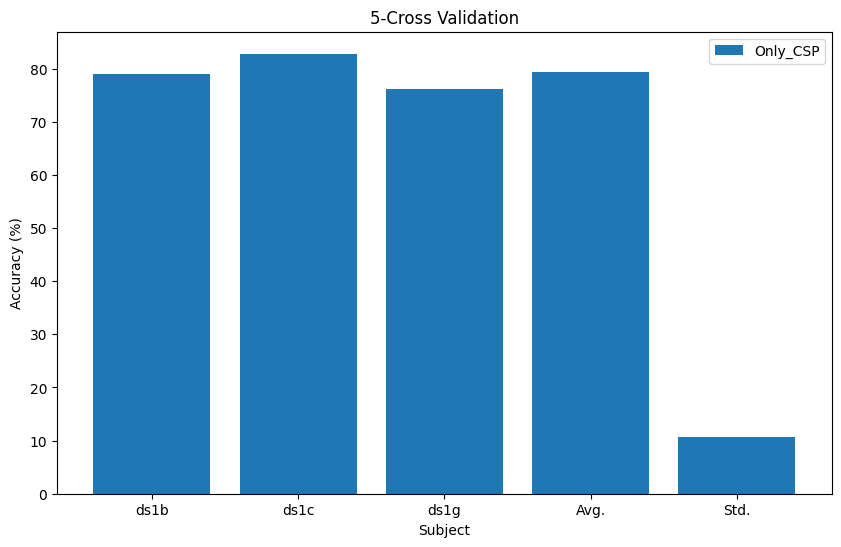

In [16]:
def robust_plot(robust_result):
    robust_result = robust_result.set_index('Subject')
    ax = robust_result.plot.bar(figsize=(10, 6), width=0.8, rot=0)
    plt.ylabel("Accuracy (%)")
    plt.title("5-Cross Validation")
    filename = saveResultPath +f"cv_score.png"
    filename = preprocess_filename(filename)
    plt.savefig(filename)
robust_plot(robust_result)


## Generalization

Confusion matrix saved to ./result_bci4_2a/ablation_accuracy.png
Confusion matrix saved to ./result_bci4_2a/ablation_precision.png
Confusion matrix saved to ./result_bci4_2a/ablation_recall.png
Confusion matrix saved to ./result_bci4_2a/ablation_f1.png
Confusion matrix saved to ./result_bci4_2a/ablation_kappa.png


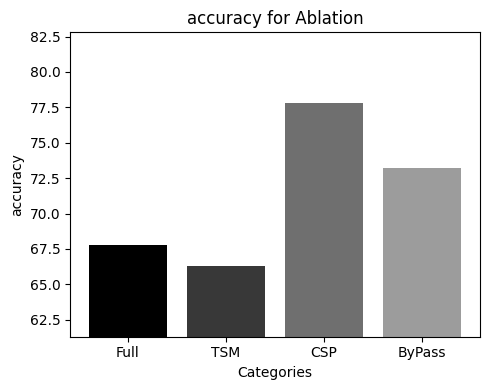

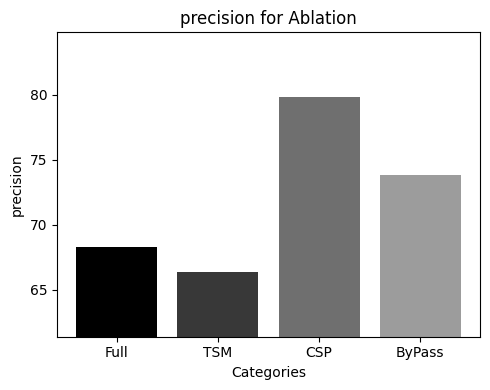

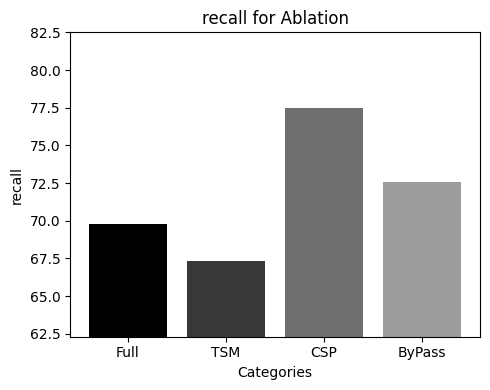

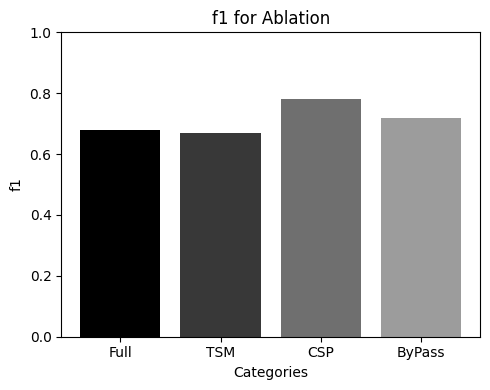

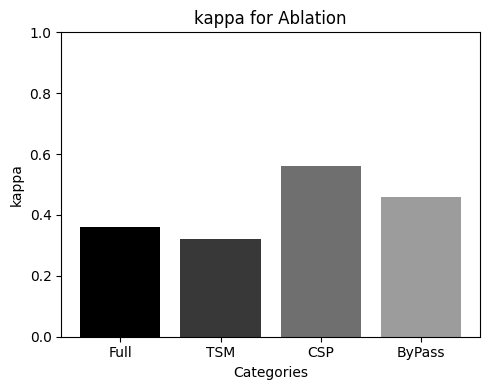

In [ ]:
ablation_comparison(test_results)

# End